#Import modules

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%pip install pydeseq2
%pip install sanbomics
%pip install scanpy
%pip install gseapy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.3/172.3 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.2/58.2 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.1/284.1 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 90.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.6/87.6 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 605.3/605.3 kB 11.2 MB/s eta 0:00:00


In [3]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
from sanbomics.tools import id_map
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#PCA
import scanpy as sc

#GSEA
import gseapy as gp
from gseapy.plot import gseaplot

#Volcano
from sanbomics.plots import volcano

#pyDESeq2

In [4]:
counts = pd.read_csv('drive/My Drive/Colab Notebooks/GP_lab_data/MCF7_isogenics_RNA_seq/RawCounts.csv')
counts = counts.rename(columns = {'Gene_ID' : 'gene_id'})

counts = counts[['gene_id', 'eV_DM1', 'eV_DM2', 'eV_DM3',
                 'PI3K_WT_DM1', 'PI3K_WT_DM2', 'PI3K_WT_DM3',
                 'E17K_DM1', 'E17K_DM2', 'E17K_DM3']]

counts = counts.rename(columns = {'eV_DM1' : 'PI3K_E545K_1',
                                  'eV_DM2' : 'PI3K_E545K_2',
                                  'eV_DM3' : 'PI3K_E545K_3',
                                  'PI3K_WT_DM1' : 'PI3K_WT_1',
                                  'PI3K_WT_DM2' : 'PI3K_WT_2',
                                  'PI3K_WT_DM3' : 'PI3K_WT_3',
                                  'E17K_DM1' : 'PI3K_WT_AKT_E17K_1',
                                  'E17K_DM2' : 'PI3K_WT_AKT_E17K_2',
                                  'E17K_DM3' : 'PI3K_WT_AKT_E17K_3'})

counts

,gene_id,PI3K_E545K_1,PI3K_E545K_2,PI3K_E545K_3,PI3K_WT_1,PI3K_WT_2,PI3K_WT_3,PI3K_WT_AKT_E17K_1,PI3K_WT_AKT_E17K_2,PI3K_WT_AKT_E17K_3
0,ENSG00000223972,0,9,3,2,5,10,4,2,14
1,ENSG00000227232,1407,1327,1275,1152,1341,1502,1210,1338,1483
2,ENSG00000278267,50,62,18,33,67,87,48,64,45
3,ENSG00000243485,2,5,2,8,8,6,6,3,10
4,ENSG00000284332,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
58730,ENSG00000271254,7058,8025,9493,5142,6120,6805,5119,5810,5681
58731,ENSG00000275405,5,3,7,4,8,13,8,8,7
58732,ENSG00000275987,0,0,0,0,4,0,0,0,0
58733,ENSG00000277475,0,0,0,0,0,0,6,0,0


In [5]:
counts = counts[['gene_id', 'PI3K_WT_1', 'PI3K_WT_2', 'PI3K_WT_3',
                 'PI3K_E545K_1', 'PI3K_E545K_2', 'PI3K_E545K_3']]
counts

,gene_id,PI3K_WT_1,PI3K_WT_2,PI3K_WT_3,PI3K_E545K_1,PI3K_E545K_2,PI3K_E545K_3
0,ENSG00000223972,2,5,10,0,9,3
1,ENSG00000227232,1152,1341,1502,1407,1327,1275
2,ENSG00000278267,33,67,87,50,62,18
3,ENSG00000243485,8,8,6,2,5,2
4,ENSG00000284332,0,0,0,0,0,0
...,...,...,...,...,...,...,...
58730,ENSG00000271254,5142,6120,6805,7058,8025,9493
58731,ENSG00000275405,4,8,13,5,3,7
58732,ENSG00000275987,0,4,0,0,0,0
58733,ENSG00000277475,0,0,0,0,0,0


In [6]:
counts = counts.set_index('gene_id')
counts

,PI3K_WT_1,PI3K_WT_2,PI3K_WT_3,PI3K_E545K_1,PI3K_E545K_2,PI3K_E545K_3
gene_id,,,,,,
ENSG00000223972,2,5,10,0,9,3
ENSG00000227232,1152,1341,1502,1407,1327,1275
ENSG00000278267,33,67,87,50,62,18
ENSG00000243485,8,8,6,2,5,2
ENSG00000284332,0,0,0,0,0,0
...,...,...,...,...,...,...
ENSG00000271254,5142,6120,6805,7058,8025,9493
ENSG00000275405,4,8,13,5,3,7
ENSG00000275987,0,4,0,0,0,0


In [7]:
counts = counts[counts.sum(axis = 1) > 0]
counts

,PI3K_WT_1,PI3K_WT_2,PI3K_WT_3,PI3K_E545K_1,PI3K_E545K_2,PI3K_E545K_3
gene_id,,,,,,
ENSG00000223972,2,5,10,0,9,3
ENSG00000227232,1152,1341,1502,1407,1327,1275
ENSG00000278267,33,67,87,50,62,18
ENSG00000243485,8,8,6,2,5,2
ENSG00000238009,2,3,1,0,0,7
...,...,...,...,...,...,...
ENSG00000278066,0,0,0,0,2,4
ENSG00000276345,7,10,7,13,2,4
ENSG00000271254,5142,6120,6805,7058,8025,9493


In [8]:
counts = counts.T

In [9]:
counts

gene_id,ENSG00000223972,ENSG00000227232,ENSG00000278267,ENSG00000243485,ENSG00000238009,ENSG00000233750,ENSG00000268903,ENSG00000269981,ENSG00000239906,ENSG00000241860,...,ENSG00000278817,ENSG00000277196,ENSG00000274917,ENSG00000278384,ENSG00000278633,ENSG00000278066,ENSG00000276345,ENSG00000271254,ENSG00000275405,ENSG00000275987
PI3K_WT_1,2,1152,33,8,2,10,251,151,1,71,...,46,177,0,254,0,0,7,5142,4,0
PI3K_WT_2,5,1341,67,8,3,11,394,224,0,57,...,54,221,0,300,0,0,10,6120,8,4
PI3K_WT_3,10,1502,87,6,1,19,437,255,4,75,...,57,273,2,378,0,0,7,6805,13,0
PI3K_E545K_1,0,1407,50,2,0,21,336,238,5,82,...,31,14,0,335,0,0,13,7058,5,0
PI3K_E545K_2,9,1327,62,5,0,22,442,291,2,77,...,46,44,0,478,6,2,2,8025,3,0
PI3K_E545K_3,3,1275,18,2,7,18,326,292,1,79,...,41,42,0,415,4,4,4,9493,7,0


In [10]:
metadata = pd.DataFrame(zip(counts.index, ['WT', 'WT', 'WT', 'MUT', 'MUT', 'MUT']),
                        columns = ['Sample', 'PI3K'])

In [11]:
metadata = metadata.set_index('Sample')
metadata

,PI3K
Sample,
PI3K_WT_1,WT
PI3K_WT_2,WT
PI3K_WT_3,WT
PI3K_E545K_1,MUT
PI3K_E545K_2,MUT
PI3K_E545K_3,MUT


In [12]:
dds = DeseqDataSet(counts=counts,
                   metadata=metadata,
                   design_factors="PI3K")

/tmp/ipython-input-1665347510.py:1: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(counts=counts,


In [13]:
dds.deseq2()

Fitting size factors...
... done in 0.11 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 49.99 seconds.

Fitting dispersion trend curve...
... done in 2.08 seconds.

Fitting MAP dispersions...
... done in 50.77 seconds.

Fitting LFCs...
... done in 32.89 seconds.

Calculating cook's distance...
... done in 0.04 seconds.

Replacing 0 outlier genes.



In [14]:
dds

AnnData object with n_obs × n_vars = 6 × 38001
    obs: 'PI3K', 'size_factors', 'replaceable'
    var: '_normed_means', 'non_zero', '_MoM_dispersions', 'genewise_dispersions', '_genewise_converged', 'fitted_dispersions', 'MAP_dispersions', '_MAP_converged', 'dispersions', '_outlier_genes', '_LFC_converged', 'replaced', 'refitted', '_pvalue_cooks_outlier'
    uns: 'trend_coeffs', 'disp_function_type', '_squared_logres', 'prior_disp_var'
    obsm: 'design_matrix', '_mu_LFC', '_hat_diagonals'
    varm: 'LFC'
    layers: 'normed_counts', '_mu_hat', 'cooks'

In [15]:
stat_res = DeseqStats(dds, contrast = ('PI3K','MUT','WT'))

In [16]:
stat_res.summary()

Running Wald tests...
... done in 12.11 seconds.



Log2 fold change & Wald test p-value: PI3K MUT vs WT
                    baseMean  log2FoldChange     lfcSE      stat  \
gene_id                                                            
ENSG00000223972     4.717460       -0.382299  1.297084 -0.294737   
ENSG00000227232  1330.272446        0.094428  0.133051  0.709714   
ENSG00000278267    52.372777       -0.376352  0.473421 -0.794964   
ENSG00000243485     5.140580       -1.206987  1.108687 -1.088664   
ENSG00000238009     2.034676        0.174356  1.939141  0.089914   
...                      ...             ...       ...       ...   
ENSG00000278066     0.965769        3.444584  3.329878  1.034448   
ENSG00000276345     7.189896       -0.216534  0.987819 -0.219205   
ENSG00000271254  7068.871757        0.518109  0.103677  4.997343   
ENSG00000275405     6.453946       -0.649054  0.985963 -0.658295   
ENSG00000275987     0.590536       -2.660825  4.236584 -0.628059   

                       pvalue      padj  
gene_id             

In [17]:
res = stat_res.results_df

In [18]:
res

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene_id,,,,,,
ENSG00000223972,4.717460,-0.382299,1.297084,-0.294737,7.681945e-01,0.873154
ENSG00000227232,1330.272446,0.094428,0.133051,0.709714,4.778816e-01,0.660448
ENSG00000278267,52.372777,-0.376352,0.473421,-0.794964,4.266344e-01,0.613560
ENSG00000243485,5.140580,-1.206987,1.108687,-1.088664,2.763022e-01,0.455574
ENSG00000238009,2.034676,0.174356,1.939141,0.089914,9.283556e-01,NaN
...,...,...,...,...,...,...
ENSG00000278066,0.965769,3.444584,3.329878,1.034448,3.009269e-01,NaN
ENSG00000276345,7.189896,-0.216534,0.987819,-0.219205,8.264907e-01,0.907844
ENSG00000271254,7068.871757,0.518109,0.103677,4.997343,5.812562e-07,0.000005


In [19]:
# res.to_csv('drive/My Drive/Colab Notebooks/GP_lab_data/MCF7_isogenics_RNA_seq/AKT_pyDESeq2_results.txt', sep = '\t')

#GSEA

In [20]:
gene_names = pd.read_csv('drive/My Drive/Colab Notebooks/GP_lab_data/BRCA1_project/SUM149_BRCA1_DESeq2/ensembl_id_gene_name.csv')
gene_names = gene_names.rename(columns = {'gene_name' : 'Symbol'})
gene_names

,gene_id,Symbol
0,ENSG00000198712,MT-CO2
1,ENSG00000198804,MT-CO1
2,ENSG00000198938,MT-CO3
3,ENSG00000198899,MT-ATP6
4,ENSG00000210082,MT-RNR2
...,...,...
58730,ENSG00000276351,RF01973
58731,ENSG00000275661,RF01974
58732,ENSG00000277856,AC233755.2
58733,ENSG00000275063,AC233755.1


In [21]:
gene_names = gene_names[gene_names['gene_id'].isin(res.index)]
gene_names = gene_names.set_index('gene_id')
gene_names

,Symbol
gene_id,
ENSG00000198712,MT-CO2
ENSG00000198804,MT-CO1
ENSG00000198938,MT-CO3
ENSG00000198899,MT-ATP6
ENSG00000210082,MT-RNR2
...,...
ENSG00000228930,MTCO1P3
ENSG00000275869,AC136612.1
ENSG00000278457,RF00001


In [22]:
res1 = pd.concat([gene_names, res], axis = 'columns')
res1.head(3)

,Symbol,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene_id,,,,,,,
ENSG00000198712,MT-CO2,1.026150e+06,-0.376521,0.098707,-3.814520,0.000136,0.000724
ENSG00000198804,MT-CO1,2.727355e+06,-0.247844,0.101921,-2.431736,0.015027,0.045994
ENSG00000198938,MT-CO3,4.977905e+05,0.034606,0.101597,0.340622,0.733388,0.851255


In [23]:
res1.sort_values(by = 'log2FoldChange', ascending = False)

,Symbol,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene_id,,,,,,,
ENSG00000082212,ME2,2103.568611,14.526346,1.942930,7.476515,7.631925e-14,1.221341e-12
ENSG00000141646,SMAD4,1796.196974,14.298389,1.941637,7.364089,1.783612e-13,2.773062e-12
ENSG00000075643,MOCOS,1454.762389,13.994198,1.941670,7.207301,5.707194e-13,8.583056e-12
ENSG00000206043,C18orf63,1343.260649,13.879393,1.943083,7.142975,9.133224e-13,1.348025e-11
ENSG00000101751,POLI,1059.632378,13.537180,1.942455,6.969108,3.189569e-12,4.479900e-11
...,...,...,...,...,...,...,...
ENSG00000163218,PGLYRP4,150.187937,-10.641639,1.951377,-5.453399,4.941600e-08,4.529166e-07
ENSG00000275216,AL161431.1,156.131855,-10.696663,1.956806,-5.466389,4.592955e-08,4.231815e-07
ENSG00000178597,PSAPL1,1331.684203,-10.934787,0.730456,-14.969801,1.156667e-50,8.564887e-49


In [24]:
ranking = res1[['Symbol', 'stat']].dropna().sort_values('stat', ascending = False)
ranking

,Symbol,stat
gene_id,,
ENSG00000162670,BRINP3,54.589346
ENSG00000138650,PCDH10,51.894454
ENSG00000171587,DSCAM,50.075020
ENSG00000175745,NR2F1,45.735679
ENSG00000107518,ATRNL1,36.336960
...,...,...
ENSG00000170477,KRT4,-48.322792
ENSG00000186832,KRT16,-52.768990
ENSG00000167755,KLK6,-53.572856


In [25]:
ranking = ranking.drop_duplicates('Symbol')

In [26]:
ranking

,Symbol,stat
gene_id,,
ENSG00000162670,BRINP3,54.589346
ENSG00000138650,PCDH10,51.894454
ENSG00000171587,DSCAM,50.075020
ENSG00000175745,NR2F1,45.735679
ENSG00000107518,ATRNL1,36.336960
...,...,...
ENSG00000170477,KRT4,-48.322792
ENSG00000186832,KRT16,-52.768990
ENSG00000167755,KLK6,-53.572856


In [27]:
ranking = ranking.set_index('Symbol')
ranking

,stat
Symbol,
BRINP3,54.589346
PCDH10,51.894454
DSCAM,50.075020
NR2F1,45.735679
ATRNL1,36.336960
...,...
KRT4,-48.322792
KRT16,-52.768990
KLK6,-53.572856


In [28]:
#manual_set = {'things':['STAU2', 'USP53', 'SERPINE1', 'TMEM178B', 'PSAP']}

In [29]:
gp.get_library_name() #to look at available libraries

['ARCHS4_Cell-lines',
 'ARCHS4_IDG_Coexp',
 'ARCHS4_Kinases_Coexp',
 'ARCHS4_TFs_Coexp',
 'ARCHS4_Tissues',
 'Achilles_fitness_decrease',
 'Achilles_fitness_increase',
 'Aging_Perturbations_from_GEO_down',
 'Aging_Perturbations_from_GEO_up',
 'Allen_Brain_Atlas_10x_scRNA_2021',
 'Allen_Brain_Atlas_down',
 'Allen_Brain_Atlas_up',
 'Azimuth_2023',
 'Azimuth_Cell_Types_2021',
 'BioCarta_2013',
 'BioCarta_2015',
 'BioCarta_2016',
 'BioPlanet_2019',
 'BioPlex_2017',
 'CCLE_Proteomics_2020',
 'CM4AI_U2OS_Protein_Localization_Assemblies',
 'COMPARTMENTS_Curated_2025',
 'COMPARTMENTS_Experimental_2025',
 'CORUM',
 'COVID-19_Related_Gene_Sets',
 'COVID-19_Related_Gene_Sets_2021',
 'Cancer_Cell_Line_Encyclopedia',
 'CellMarker_2024',
 'CellMarker_Augmented_2021',
 'ChEA_2013',
 'ChEA_2015',
 'ChEA_2016',
 'ChEA_2022',
 'Chromosome_Location',
 'Chromosome_Location_hg19',
 'ClinVar_2019',
 'ClinVar_2025',
 'DGIdb_Drug_Targets_2024',
 'DSigDB',
 'Data_Acquisition_Method_Most_Popular_Genes',
 'DepMa

In [30]:
pre_res = gp.prerank(rnk = ranking, gene_sets = 'KEGG_2021_Human', seed = 6, permutation_num = 100)

2025-12-05 17:13:29,879 [WARNING] Duplicated values found in preranked stats: 19.65% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


In [31]:
out = []

for term in list(pre_res.results):
    out.append([term,
               pre_res.results[term]['fdr'],
               pre_res.results[term]['es'],
               pre_res.results[term]['nes']])

out_df = pd.DataFrame(out, columns = ['Term','fdr', 'es', 'nes']).sort_values('fdr').reset_index(drop = True)
out_df

,Term,fdr,es,nes
0,Staphylococcus aureus infection,0.000000,-0.744958,-2.224375
1,Cytokine-cytokine receptor interaction,0.001965,-0.552158,-1.905016
2,Influenza A,0.002358,-0.595175,-1.954645
3,Hepatitis C,0.002948,-0.596456,-1.965453
4,Complement and coagulation cascades,0.002948,-0.622536,-1.860535
...,...,...,...,...
301,Ascorbate and aldarate metabolism,0.849623,-0.327376,-0.793874
302,Butanoate metabolism,0.900768,0.322197,0.777375
303,Linoleic acid metabolism,0.917725,-0.304798,-0.739039
304,One carbon pool by folate,0.929257,-0.296343,-0.723354


In [32]:
import string

kegg_metabolic_pathways = pd.read_csv('drive/My Drive/Colab Notebooks/GP_lab_data/MCF10A_PIK3CA_isogenics_RNA_seq_analysis/MCF_PI3K_featureCounts/KEGG_metabolic_pathways.csv')
kegg_metabolic_pathways = kegg_metabolic_pathways[['1. Metabolism']].dropna()
kegg_metabolic_pathways

list_kegg_mp = []
for i in kegg_metabolic_pathways['1. Metabolism']:
  if i[0].isdigit():
    pass
  else:
    list_kegg_mp.append(i)
list_kegg_mp

['Metabolic pathways',
 'Biosynthesis of secondary metabolites',
 'Microbial metabolism in diverse environments',
 'Carbon metabolism',
 'Fatty acid metabolism',
 'Biosynthesis of amino acids',
 'Nucleotide metabolism',
 'Biosynthesis of nucleotide sugars',
 'Biosynthesis of cofactors',
 'Degradation of aromatic compounds',
 'Glycolysis / Gluconeogenesis',
 'Citrate cycle (TCA cycle)',
 'Pentose phosphate pathway',
 'Pentose and glucuronate interconversions',
 'Fructose and mannose metabolism',
 'Galactose metabolism',
 'Ascorbate and aldarate metabolism',
 'Starch and sucrose metabolism',
 'Amino sugar and nucleotide sugar metabolism',
 'Pyruvate metabolism',
 'Glyoxylate and dicarboxylate metabolism',
 'Propanoate metabolism',
 'Butanoate metabolism',
 'C5-Branched dibasic acid metabolism',
 'Inositol phosphate metabolism',
 'Oxidative phosphorylation',
 'Photosynthesis',
 'Photosynthesis - antenna proteins',
 'Carbon fixation in photosynthetic organisms',
 'Carbon fixation pathways 

In [33]:
metabolic_out_df = out_df[out_df['Term'].isin(list_kegg_mp)]
metabolic_out_df = metabolic_out_df.sort_values('nes', ascending = True)
metabolic_out_df

,Term,fdr,es,nes
8,Arginine and proline metabolism,0.005895,-0.616706,-1.802728
19,Thiamine metabolism,0.031648,-0.775596,-1.681618
34,Glyoxylate and dicarboxylate metabolism,0.069009,-0.651493,-1.558492
38,Steroid hormone biosynthesis,0.084706,-0.535936,-1.527596
56,Retinol metabolism,0.104936,-0.523744,-1.476069
...,...,...,...,...
143,Mannose type O-glycan biosynthesis,0.250152,0.549330,1.291365
140,Purine metabolism,0.247175,0.377586,1.317601
109,Terpenoid backbone biosynthesis,0.169649,0.562969,1.415699
108,Inositol phosphate metabolism,0.164377,0.465880,1.425487


<Axes: title={'center': 'KEGG metabolic pathways'}, xlabel='nes', ylabel='Term'>

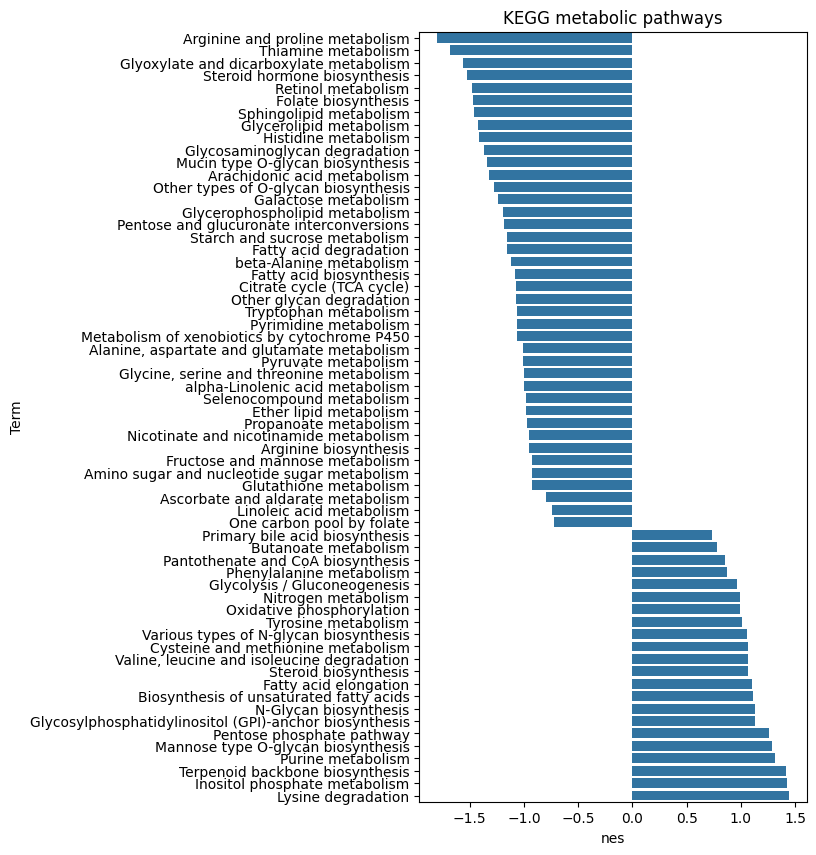

In [34]:
plt.figure(figsize = (5,10))
plt.title('KEGG metabolic pathways')
sns.barplot(data = metabolic_out_df,
            x = 'nes',
            y = 'Term')

In [35]:
pre_res.res2d.sort_values('NES').head(5)

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,Staphylococcus aureus infection,-0.744958,-2.224375,0.0,0.0,0.0,21/77,5.35%,KRT16;KRT15;KRT17;KRT13;KRT23;KRT9;C5AR1;C3;KR...
1,prerank,Viral protein interaction with cytokine and cy...,-0.627824,-1.995083,0.0,0.005895,0.01,25/79,10.67%,IL24;CX3CL1;CCL5;CSF1R;CSF1;IL18;IL2RB;CCL22;T...
2,prerank,Coronavirus disease,-0.599944,-1.979025,0.0,0.00393,0.01,79/204,12.47%,OAS2;ISG15;DDX58;OAS3;IRF9;OAS1;C5AR1;PIK3CD;S...
3,prerank,Hepatitis C,-0.596456,-1.965453,0.0,0.002948,0.01,44/141,11.46%,OAS2;IFIT1;CLDN1;IRF7;DDX58;OAS3;IRF9;OAS1;RSA...
4,prerank,Influenza A,-0.595175,-1.954645,0.0,0.002358,0.01,46/153,10.11%,OAS2;IRF7;DDX58;OAS3;CCL5;IRF9;OAS1;RSAD2;PIK3...


In [36]:
gsea_data_set = pre_res.res2d.sort_values('NES')
gsea_data_set

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,Staphylococcus aureus infection,-0.744958,-2.224375,0.0,0.0,0.0,21/77,5.35%,KRT16;KRT15;KRT17;KRT13;KRT23;KRT9;C5AR1;C3;KR...
1,prerank,Viral protein interaction with cytokine and cy...,-0.627824,-1.995083,0.0,0.005895,0.01,25/79,10.67%,IL24;CX3CL1;CCL5;CSF1R;CSF1;IL18;IL2RB;CCL22;T...
2,prerank,Coronavirus disease,-0.599944,-1.979025,0.0,0.00393,0.01,79/204,12.47%,OAS2;ISG15;DDX58;OAS3;IRF9;OAS1;C5AR1;PIK3CD;S...
3,prerank,Hepatitis C,-0.596456,-1.965453,0.0,0.002948,0.01,44/141,11.46%,OAS2;IFIT1;CLDN1;IRF7;DDX58;OAS3;IRF9;OAS1;RSA...
4,prerank,Influenza A,-0.595175,-1.954645,0.0,0.002358,0.01,46/153,10.11%,OAS2;IRF7;DDX58;OAS3;CCL5;IRF9;OAS1;RSAD2;PIK3...
...,...,...,...,...,...,...,...,...,...,...
29,prerank,RNA transport,0.456694,1.624235,0.0,0.093627,0.43,47/171,11.85%,UPF3B;GLE1;SENP2;NXT2;EIF4G1;FXR1;RAE1;NCBP1;N...
24,prerank,Progesterone-mediated oocyte maturation,0.485172,1.650403,0.0,0.093627,0.36,36/94,13.88%,PGR;MAPK9;AURKA;PDE3B;PRKACB;CPEB4;CPEB2;ADCY1...
23,prerank,Spliceosome,0.480324,1.672088,0.0,0.096028,0.32,64/140,23.99%,NCBP1;THOC1;PRPF3;PRPF4;THOC2;BCAS2;RBMXL1;HSP...
12,prerank,Ubiquitin mediated proteolysis,0.498257,1.757334,0.0,0.06842,0.18,66/139,15.68%,KLHL13;UBE2A;TRIM32;CUL4B;RHOBTB1;UBE2QL1;FBXW...


In [37]:
pyrimidine_gene_sig = gsea_data_set[gsea_data_set['Term'] == 'Pyrimidine metabolism']['Lead_genes'].iloc[0]
pyrimidine_gene_sig = pyrimidine_gene_sig.split(';')
pyrimidine_gene_sig

['TYMP',
 'CMPK2',
 'UPP1',
 'PNP',
 'CAD',
 'ENTPD8',
 'TK2',
 'CDA',
 'NME2',
 'DPYD',
 'CTPS2',
 'NME3',
 'DCTPP1',
 'NT5C3B',
 'UCKL1',
 'NT5C2',
 'ENPP3',
 'NT5C1A',
 'DPYS',
 'UPP2',
 'ENTPD6']

In [38]:
purine_gene_sig = gsea_data_set[gsea_data_set['Term'] == 'Purine metabolism']['Lead_genes'].iloc[0]
purine_gene_sig = purine_gene_sig.split(';')
purine_gene_sig

['GUCY1A2',
 'PGM1',
 'PRPS1',
 'PDE4D',
 'PDE3B',
 'GUCY1A1',
 'PDE10A',
 'HPRT1',
 'PDE7A',
 'ADCY1',
 'ENTPD4',
 'ADCY6',
 'PDE8A',
 'NUDT16',
 'GUCY1B1',
 'PDE9A',
 'ENTPD1',
 'RRM2',
 'PRUNE1',
 'NME1',
 'DCK',
 'GMPS',
 'PDE4B',
 'AK1',
 'NME6',
 'ENPP1',
 'RRM2B',
 'AK9',
 'ADA',
 'RRM1']

In [39]:
glycerolipid_gene_sig = gsea_data_set[gsea_data_set['Term'] == 'Glycerolipid metabolism']['Lead_genes'].iloc[0]
glycerolipid_gene_sig = glycerolipid_gene_sig.split(';')
glycerolipid_gene_sig

['PNPLA3',
 'AKR1B10',
 'PLPP1',
 'MBOAT1',
 'PLPP3',
 'PLPP4',
 'DGAT2',
 'ALDH7A1',
 'DGKA',
 'AGPAT4',
 'DGKQ',
 'PNLIPRP3',
 'CEL',
 'MGLL',
 'AKR1B1',
 'AGPAT3',
 'LIPC',
 'LCLAT1',
 'ALDH2',
 'DGAT1',
 'PNLIPRP1',
 'MOGAT2',
 'ALDH3A2',
 'AGPAT2']

In [40]:
aag_sig = gsea_data_set[gsea_data_set['Term'] == 'Alanine, aspartate and glutamate metabolism']['Lead_genes'].iloc[0]
aag_sig = str(aag_sig).split(';')
aag_sig

['GLUL',
 'AGXT',
 'GFPT2',
 'NAT8L',
 'GAD1',
 'ALDH5A1',
 'CAD',
 'GPT',
 'GLS2',
 'ASL',
 'ABAT']

In [41]:
selected_processess = pd.concat([gsea_data_set.head(10), gsea_data_set.tail(10)], axis = 'index')
selected_processess

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,Staphylococcus aureus infection,-0.744958,-2.224375,0.0,0.0,0.0,21/77,5.35%,KRT16;KRT15;KRT17;KRT13;KRT23;KRT9;C5AR1;C3;KR...
1,prerank,Viral protein interaction with cytokine and cy...,-0.627824,-1.995083,0.0,0.005895,0.01,25/79,10.67%,IL24;CX3CL1;CCL5;CSF1R;CSF1;IL18;IL2RB;CCL22;T...
2,prerank,Coronavirus disease,-0.599944,-1.979025,0.0,0.00393,0.01,79/204,12.47%,OAS2;ISG15;DDX58;OAS3;IRF9;OAS1;C5AR1;PIK3CD;S...
3,prerank,Hepatitis C,-0.596456,-1.965453,0.0,0.002948,0.01,44/141,11.46%,OAS2;IFIT1;CLDN1;IRF7;DDX58;OAS3;IRF9;OAS1;RSA...
4,prerank,Influenza A,-0.595175,-1.954645,0.0,0.002358,0.01,46/153,10.11%,OAS2;IRF7;DDX58;OAS3;CCL5;IRF9;OAS1;RSAD2;PIK3...
5,prerank,Cytokine-cytokine receptor interaction,-0.552158,-1.905016,0.0,0.001965,0.01,69/241,11.12%,IL24;INHBB;CX3CL1;TGFB2;INHA;IL1RN;TNFSF15;CCL...
6,prerank,Aldosterone-regulated sodium reabsorption,-0.705891,-1.872771,0.0,0.003369,0.02,14/36,7.67%,SGK1;SCNN1B;HSD11B2;SCNN1G;PIK3CD;ATP1B1;NEDD4...
7,prerank,Complement and coagulation cascades,-0.622536,-1.860535,0.0,0.002948,0.02,23/77,10.06%,BDKRB2;C5AR1;SERPINE1;PLAT;C3;BDKRB1;A2M;ITGAM...
8,prerank,Protein digestion and absorption,-0.596061,-1.827537,0.0,0.00524,0.04,34/100,12.05%,MME;COL12A1;SLC7A7;ATP1B1;COL18A1;COL4A4;COL4A...
9,prerank,Arginine and proline metabolism,-0.616706,-1.802728,0.0,0.005895,0.05,18/49,12.88%,AOC1;SAT1;MAOA;SMOX;LAP3;ARG1;ALDH7A1;AZIN2;NO...


<Axes: title={'center': 'KEGG all pathways (Top 10 up/down)'}, xlabel='NES', ylabel='Term'>

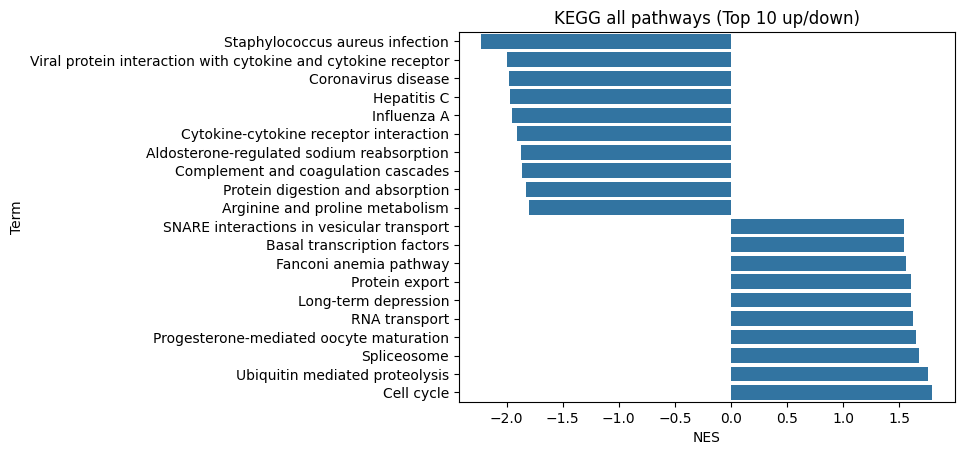

In [42]:
plt.title('KEGG all pathways (Top 10 up/down)')
sns.barplot(data = selected_processess,
            x = 'NES',
            y = 'Term')

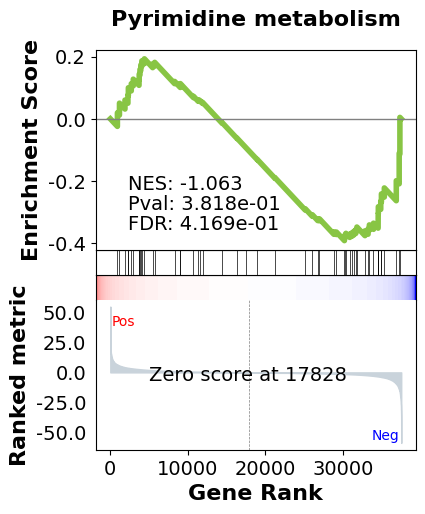

In [43]:
terms = pre_res.res2d.Term
axs = pre_res.plot(terms='Pyrimidine metabolism')
plt.savefig('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/mcf7_pyrimidine_gsea.svg', bbox_inches = 'tight')

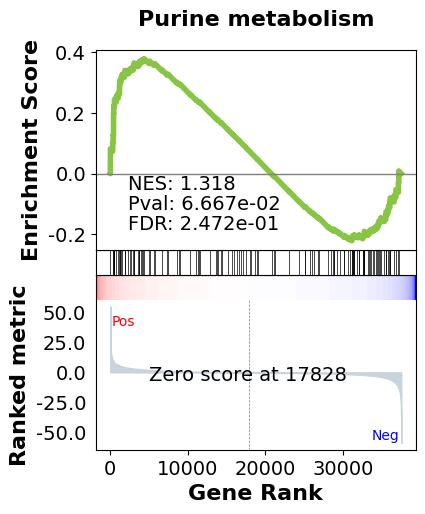

In [44]:
terms = pre_res.res2d.Term
axs = pre_res.plot(terms='Purine metabolism')
plt.savefig('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/mcf7_purine_gsea.svg', bbox_inches = 'tight')

#DESeq2 visualization

In [45]:
mapper = id_map(species = 'human')
res['Symbol'] = res.index.map(mapper.mapper)

In [46]:
res

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Symbol
gene_id,,,,,,,
ENSG00000223972,4.717460,-0.382299,1.297084,-0.294737,7.681945e-01,0.873154,DDX11L1
ENSG00000227232,1330.272446,0.094428,0.133051,0.709714,4.778816e-01,0.660448,WASH7P
ENSG00000278267,52.372777,-0.376352,0.473421,-0.794964,4.266344e-01,0.613560,MIR6859-1
ENSG00000243485,5.140580,-1.206987,1.108687,-1.088664,2.763022e-01,0.455574,MIR1302-2HG
ENSG00000238009,2.034676,0.174356,1.939141,0.089914,9.283556e-01,NaN,AL627309.1
...,...,...,...,...,...,...,...
ENSG00000278066,0.965769,3.444584,3.329878,1.034448,3.009269e-01,NaN,NaN
ENSG00000276345,7.189896,-0.216534,0.987819,-0.219205,8.264907e-01,0.907844,AC004556.3
ENSG00000271254,7068.871757,0.518109,0.103677,4.997343,5.812562e-07,0.000005,AC240274.1


In [47]:
res = res[res.baseMean >= 10]
res

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Symbol
gene_id,,,,,,,
ENSG00000227232,1330.272446,0.094428,0.133051,0.709714,4.778816e-01,6.604476e-01,WASH7P
ENSG00000278267,52.372777,-0.376352,0.473421,-0.794964,4.266344e-01,6.135605e-01,MIR6859-1
ENSG00000233750,16.903989,0.703929,0.617686,1.139624,2.544431e-01,4.303043e-01,CICP27
ENSG00000268903,361.825102,0.135030,0.202641,0.666348,5.051884e-01,6.838723e-01,NaN
ENSG00000269981,240.163534,0.472629,0.199612,2.367739,1.789714e-02,5.312998e-02,NaN
...,...,...,...,...,...,...,...
ENSG00000273748,243.067955,0.398345,0.188781,2.110095,3.485016e-02,9.295149e-02,AL592183.1
ENSG00000278817,45.370508,-0.332752,0.379206,-0.877498,3.802164e-01,5.675747e-01,AC007325.4
ENSG00000277196,124.390955,-2.675391,0.319761,-8.366834,5.918722e-17,1.180727e-15,AC007325.2


In [48]:
sigs = res[(res.padj < 0.05) & (abs(res.log2FoldChange) > 0.5)]
sigs

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Symbol
gene_id,,,,,,,
ENSG00000223764,2178.562322,1.049558,0.157104,6.680674,2.378457e-11,3.062205e-10,LINC02593
ENSG00000187634,3805.187170,1.166275,0.112586,10.358939,3.811647e-25,1.192300e-23,SAMD11
ENSG00000187961,5910.321786,-0.623054,0.214188,-2.908908,3.626934e-03,1.352913e-02,KLHL17
ENSG00000187583,1872.851093,-0.765303,0.137965,-5.547076,2.904865e-08,2.738052e-07,PLEKHN1
ENSG00000187642,550.637289,-0.812953,0.163563,-4.970262,6.686237e-07,5.293456e-06,PERM1
...,...,...,...,...,...,...,...
ENSG00000160282,645.873849,-0.548650,0.188761,-2.906593,3.653888e-03,1.360889e-02,FTCD
ENSG00000210082,565256.332107,-0.553578,0.125418,-4.413854,1.015467e-05,6.720128e-05,MT-RNR2
ENSG00000276256,319.033227,0.689906,0.183958,3.750342,1.765938e-04,9.133887e-04,AC011043.1


In [49]:
dds

AnnData object with n_obs × n_vars = 6 × 38001
    obs: 'PI3K', 'size_factors', 'replaceable'
    var: '_normed_means', 'non_zero', '_MoM_dispersions', 'genewise_dispersions', '_genewise_converged', 'fitted_dispersions', 'MAP_dispersions', '_MAP_converged', 'dispersions', '_outlier_genes', '_LFC_converged', 'replaced', 'refitted', '_pvalue_cooks_outlier'
    uns: 'trend_coeffs', 'disp_function_type', '_squared_logres', 'prior_disp_var'
    obsm: 'design_matrix', '_mu_LFC', '_hat_diagonals'
    varm: 'LFC'
    layers: 'normed_counts', '_mu_hat', 'cooks'

In [50]:
sc.tl.pca(dds)

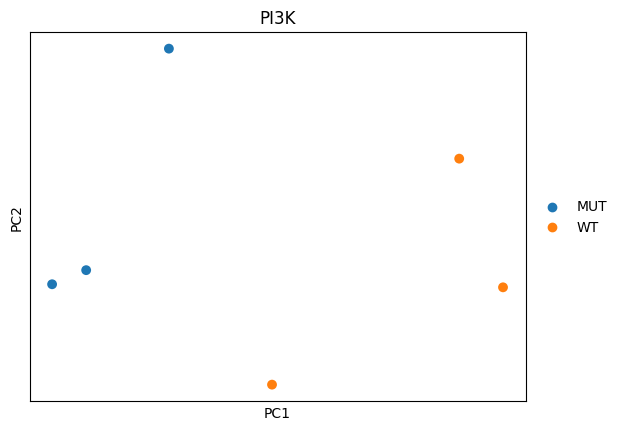

In [51]:
sc.pl.pca(dds, color = 'PI3K', size = 200)

In [52]:
dds.layers['normed_counts']

array([[2.20090760e+00, 1.26772278e+03, 3.63149754e+01, ...,
        5.65853344e+03, 4.40181520e+00, 0.00000000e+00],
       [4.42901824e+00, 1.18786269e+03, 5.93488444e+01, ...,
        5.42111832e+03, 7.08642918e+00, 3.54321459e+00],
       [9.34582606e+00, 1.40374307e+03, 8.13086867e+01, ...,
        6.35983463e+03, 1.21495739e+01, 0.00000000e+00],
       [0.00000000e+00, 1.54136500e+03, 5.47748757e+01, ...,
        7.73202146e+03, 5.47748757e+00, 0.00000000e+00],
       [9.57965357e+00, 1.41246670e+03, 6.59931690e+01, ...,
        8.54185777e+03, 3.19321786e+00, 0.00000000e+00],
       [2.74935160e+00, 1.16847443e+03, 1.64961096e+01, ...,
        8.69986493e+03, 6.41515374e+00, 0.00000000e+00]])

In [53]:
dds.layers['log1p'] = np.log1p(dds.layers['normed_counts'])

In [54]:
dds.layers['log1p']

array([[1.16343439, 7.14576599, 3.61939473, ..., 8.64109674, 1.68673505,
        0.        ],
       [1.69175831, 7.08075241, 4.1001418 , ..., 8.59824185, 2.09018725,
        1.51363482],
       [2.33658316, 7.2476097 , 4.41047665, ..., 8.75791488, 2.57638935,
        0.        ],
       [0.        , 7.34107223, 4.02132351, ..., 8.95325494, 1.86833271,
        0.        ],
       [2.35893268, 7.25380062, 4.20459066, ..., 9.05285086, 1.43346842,
        0.        ],
       [1.32158292, 7.06430972, 2.86197855, ..., 9.07117772, 2.00352571,
        0.        ]])

In [55]:
sigs

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Symbol
gene_id,,,,,,,
ENSG00000223764,2178.562322,1.049558,0.157104,6.680674,2.378457e-11,3.062205e-10,LINC02593
ENSG00000187634,3805.187170,1.166275,0.112586,10.358939,3.811647e-25,1.192300e-23,SAMD11
ENSG00000187961,5910.321786,-0.623054,0.214188,-2.908908,3.626934e-03,1.352913e-02,KLHL17
ENSG00000187583,1872.851093,-0.765303,0.137965,-5.547076,2.904865e-08,2.738052e-07,PLEKHN1
ENSG00000187642,550.637289,-0.812953,0.163563,-4.970262,6.686237e-07,5.293456e-06,PERM1
...,...,...,...,...,...,...,...
ENSG00000160282,645.873849,-0.548650,0.188761,-2.906593,3.653888e-03,1.360889e-02,FTCD
ENSG00000210082,565256.332107,-0.553578,0.125418,-4.413854,1.015467e-05,6.720128e-05,MT-RNR2
ENSG00000276256,319.033227,0.689906,0.183958,3.750342,1.765938e-04,9.133887e-04,AC011043.1


In [56]:
dds_sigs = dds[:, sigs.index]
dds_sigs

View of AnnData object with n_obs × n_vars = 6 × 5663
    obs: 'PI3K', 'size_factors', 'replaceable'
    var: '_normed_means', 'non_zero', '_MoM_dispersions', 'genewise_dispersions', '_genewise_converged', 'fitted_dispersions', 'MAP_dispersions', '_MAP_converged', 'dispersions', '_outlier_genes', '_LFC_converged', 'replaced', 'refitted', '_pvalue_cooks_outlier'
    uns: 'trend_coeffs', 'disp_function_type', '_squared_logres', 'prior_disp_var', 'pca', 'PI3K_colors'
    obsm: 'design_matrix', '_mu_LFC', '_hat_diagonals', 'X_pca'
    varm: 'LFC', 'PCs'
    layers: 'normed_counts', '_mu_hat', 'cooks', 'log1p'

In [57]:
grapher = pd.DataFrame(dds_sigs.layers['log1p'].T,
                       index=dds_sigs.var_names, columns=dds_sigs.obs_names)

/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


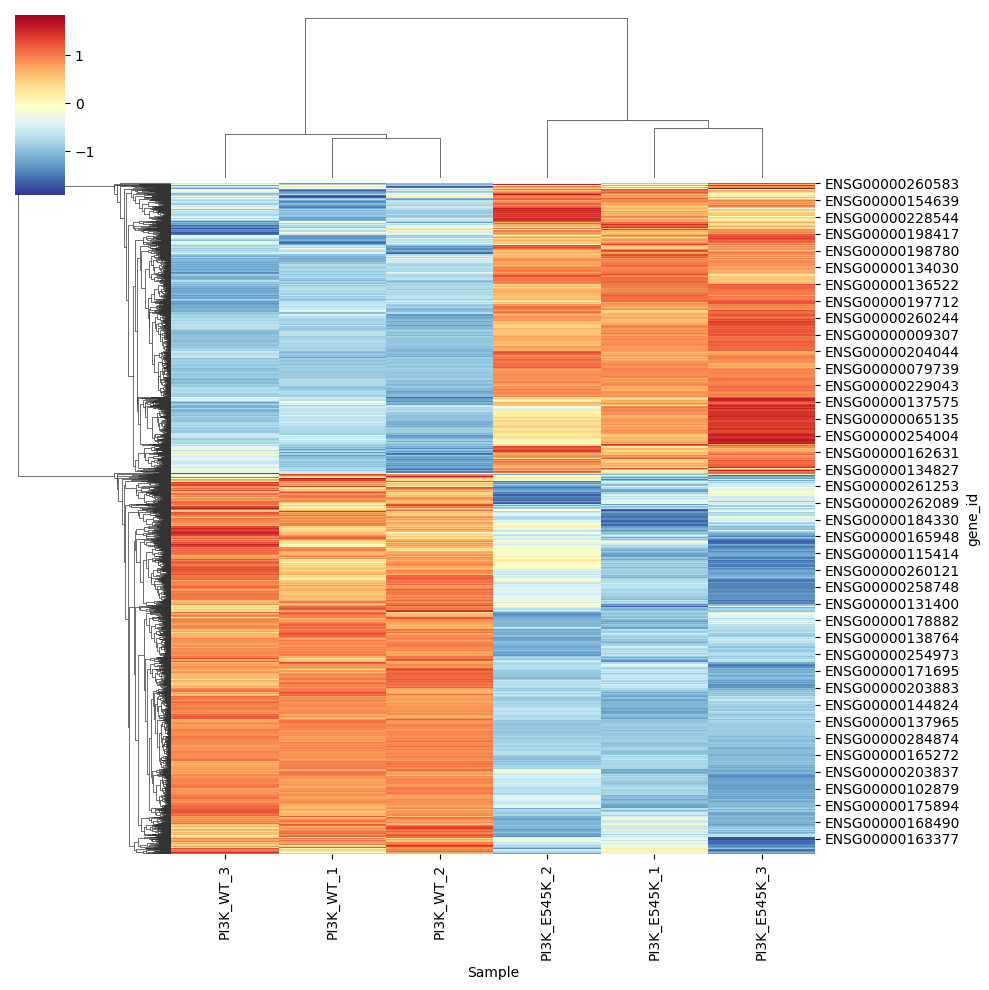

In [58]:
sns.clustermap(grapher, z_score=0, cmap = 'RdYlBu_r')

In [59]:
'''

pyrimidine_gene_sig
purine_gene_sig
glycerolipid_gene_sig

'''

'\n\npyrimidine_gene_sig\npurine_gene_sig\nglycerolipid_gene_sig\n\n'

In [60]:
sigs[sigs.Symbol.isin(pyrimidine_gene_sig)].index

Index(['ENSG00000158825', 'ENSG00000188641', 'ENSG00000134326',
       'ENSG00000183696', 'ENSG00000188833', 'ENSG00000025708'],
      dtype='object', name='gene_id')

In [61]:
dds_sub = dds[:, sigs[sigs.Symbol.isin(pyrimidine_gene_sig)].index]

In [62]:
dds_sub

View of AnnData object with n_obs × n_vars = 6 × 6
    obs: 'PI3K', 'size_factors', 'replaceable'
    var: '_normed_means', 'non_zero', '_MoM_dispersions', 'genewise_dispersions', '_genewise_converged', 'fitted_dispersions', 'MAP_dispersions', '_MAP_converged', 'dispersions', '_outlier_genes', '_LFC_converged', 'replaced', 'refitted', '_pvalue_cooks_outlier'
    uns: 'trend_coeffs', 'disp_function_type', '_squared_logres', 'prior_disp_var', 'pca', 'PI3K_colors'
    obsm: 'design_matrix', '_mu_LFC', '_hat_diagonals', 'X_pca'
    varm: 'LFC', 'PCs'
    layers: 'normed_counts', '_mu_hat', 'cooks', 'log1p'

In [63]:
grapher = pd.DataFrame(dds_sub.layers['log1p'].T,
                       index=dds_sub.var_names, columns=dds_sub.obs_names)

In [64]:
grapher.index = grapher.index.map(mapper.mapper)

In [65]:
grapher

Sample,PI3K_WT_1,PI3K_WT_2,PI3K_WT_3,PI3K_E545K_1,PI3K_E545K_2,PI3K_E545K_3
gene_id,,,,,,
CDA,4.537299,3.688263,4.548158,1.160333,2.454796,0.000000
DPYD,3.558602,3.975231,3.489691,1.160333,1.999645,3.135269
CMPK2,7.361089,7.085213,6.964148,5.358617,5.161914,5.515208
UPP1,6.951035,7.113731,6.956166,6.154791,5.986511,5.799110
ENTPD8,5.726607,5.940497,6.021548,5.238196,5.611257,5.117260
TYMP,7.672286,7.759971,7.491941,5.946031,6.005057,5.759455


Text(0.5, 1.0, 'Pyrimidine metabolism genes')

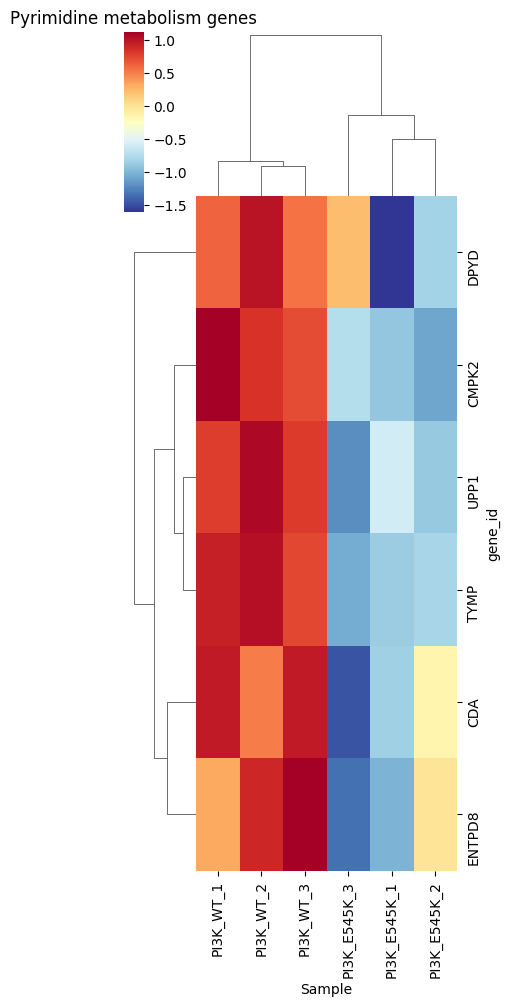

In [66]:
ax = sns.clustermap(grapher, z_score=0, cmap = 'RdYlBu_r', figsize=(4,10))
plt.title('Pyrimidine metabolism genes')

In [67]:
res

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Symbol
gene_id,,,,,,,
ENSG00000227232,1330.272446,0.094428,0.133051,0.709714,4.778816e-01,6.604476e-01,WASH7P
ENSG00000278267,52.372777,-0.376352,0.473421,-0.794964,4.266344e-01,6.135605e-01,MIR6859-1
ENSG00000233750,16.903989,0.703929,0.617686,1.139624,2.544431e-01,4.303043e-01,CICP27
ENSG00000268903,361.825102,0.135030,0.202641,0.666348,5.051884e-01,6.838723e-01,NaN
ENSG00000269981,240.163534,0.472629,0.199612,2.367739,1.789714e-02,5.312998e-02,NaN
...,...,...,...,...,...,...,...
ENSG00000273748,243.067955,0.398345,0.188781,2.110095,3.485016e-02,9.295149e-02,AL592183.1
ENSG00000278817,45.370508,-0.332752,0.379206,-0.877498,3.802164e-01,5.675747e-01,AC007325.4
ENSG00000277196,124.390955,-2.675391,0.319761,-8.366834,5.918722e-17,1.180727e-15,AC007325.2


0s encountered for p value, imputing 1e-323
impute your own value if you want to avoid this


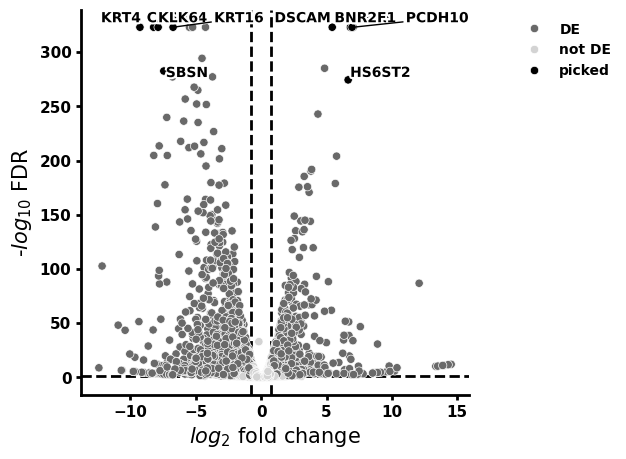

In [68]:
volcano(res, symbol='Symbol')

In [69]:
grapher.index

Index(['CDA', 'DPYD', 'CMPK2', 'UPP1', 'ENTPD8', 'TYMP'], dtype='object', name='gene_id')

0s encountered for p value, imputing 1e-323
impute your own value if you want to avoid this


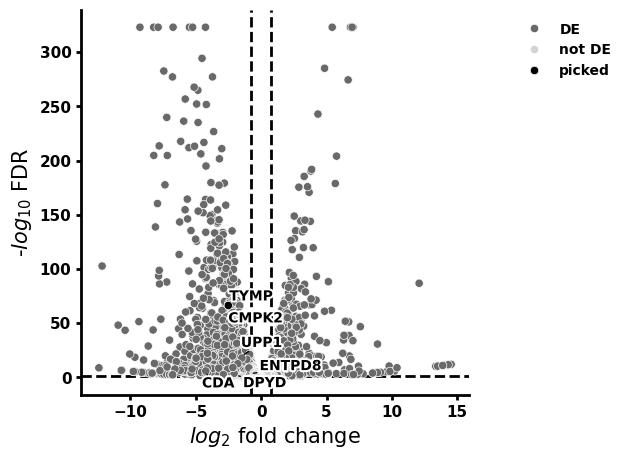

In [70]:
volcano(res, symbol='Symbol', to_label = grapher.index)